In [5]:
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [6]:
uv10_d05_pangu_24h = xr.open_dataset('./data/uv10_d05_pangu_24h.nc')
uv10_d05_graphcast_24h = xr.open_dataset('./data/uv10_d05_graphcast_24h.nc')
uv10_d05_fengwu_24h = xr.open_dataset('./data/uv10_d05_fengwu_24h.nc')
uv10_d05_fuxi_24h = xr.open_dataset('./data/uv10_d05_fuxi_24h.nc')
uv10_d05_aurora_24h = xr.open_dataset('./data/uv10_d05_aurora_24h.nc')

Shared color range: vmin=0.676, vmax=77.274 (m/s)


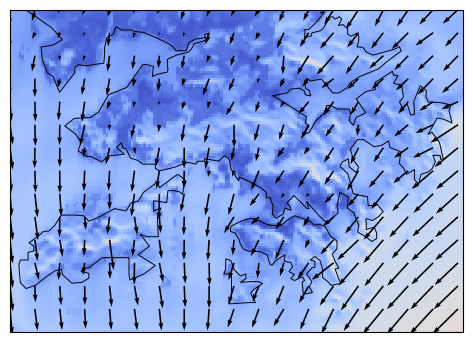

Saved 15 snapshot maps to: E:\CityU\Paper Code\06_AI_WRF_UCM\Figs\Fig5\publish


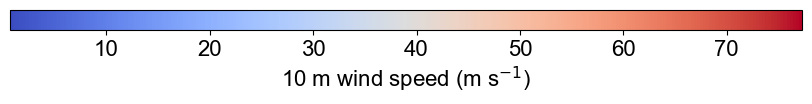

Saved standalone colorbar: E:\CityU\Paper Code\06_AI_WRF_UCM\Figs\Fig5\publish\colorbar_wind10.tif


In [7]:
# --- configuration ---
TIMES_TO_PLOT = [
    '2025-09-23_21:00:00',
    '2025-09-23_22:00:00',
    '2025-09-23_23:00:00',
]

MODEL_DATASETS = {
    'pangu': uv10_d05_pangu_24h,
    'graphcast': uv10_d05_graphcast_24h,
    'fengwu': uv10_d05_fengwu_24h,
    'fuxi': uv10_d05_fuxi_24h,
    'aurora': uv10_d05_aurora_24h,
}

OUTPUT_DIR = Path('./publish')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Fig1-style constants
PLOT_CMAP = 'coolwarm'
QUIVER_STEP = 10
QUIVER_SCALE = 500
QUIVER_WIDTH = 0.0035
QUIVER_HEADWIDTH = 3.0
QUIVER_COLOR = 'black'
FIGSIZE = (6, 6)
DPI = 600

# shared legend styling
LEGEND_FONTSIZE = 16
QUIVERKEY_U = 40  # m/s shown in arrow label
QUIVERKEY_SCALE = 180  # standalone legend arrow length
QUIVERKEY_WIDTH = 0.0060  # standalone legend arrow thickness
QUIVERKEY_HEADWIDTH = 6.0  # larger head for standalone arrow label

# quick in-notebook previews (only 1 map + legends)
SHOW_PREVIEW = True
PREVIEW_MODEL = 'pangu'
PREVIEW_TIME = TIMES_TO_PLOT[0]

# No titles (per requirement)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12


def _time_tag(time_str: str) -> str:
    # '2025-09-23_21:00:00' -> '20250923_210000'
    date_part, clock_part = time_str.split('_')
    return f"{date_part.replace('-', '')}_{clock_part.replace(':', '')}"


def _times_to_strings(times_da: xr.DataArray) -> np.ndarray:
    # Handles either 1D object strings or 2D char arrays.
    values = times_da.values
    if times_da.ndim == 1:
        return values.astype(str)
    if times_da.ndim == 2:
        # Common WRF pattern: (Time, DateStrLen) char array
        return np.array([''.join(row.astype(str)) for row in values])
    raise ValueError(f"Unsupported TIMES ndim={times_da.ndim}")


def _select_time(ds: xr.Dataset, time_str: str) -> xr.Dataset:
    # Prefer selection via coordinate if available; otherwise index via ds['TIMES'] variable.
    if 'TIMES' in ds.coords:
        try:
            return ds.sel(TIMES=time_str)
        except Exception:
            return ds.where(ds['TIMES'] == time_str, drop=True).squeeze()

    if 'TIMES' in ds:
        times_da = ds['TIMES']
        time_dim = times_da.dims[0]
        times_strings = _times_to_strings(times_da)
        matches = np.where(times_strings == time_str)[0]
        if len(matches) == 0:
            raise KeyError(f"Requested time not found in TIMES: {time_str}")
        return ds.isel({time_dim: int(matches[0])}).squeeze()

    raise KeyError("Dataset has no usable TIMES/time coordinate")


def _get_uv_latlon(ds_t: xr.Dataset):
    u10 = ds_t['U10'].squeeze()
    v10 = ds_t['V10'].squeeze()
    lat = ds_t['LAT'].squeeze()
    lon = ds_t['LON'].squeeze()
    return u10, v10, lat, lon


def _plot_one_map(u10, v10, lat, lon, speed, *, norm, cmap):
    fig = plt.figure(figsize=FIGSIZE)
    fig.subplots_adjust(right=0.88)  # match Fig1 layout
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([
        float(lon.min()),
        float(lon.max()),
        float(lat.min()),
        float(lat.max()),
    ], crs=ccrs.PlateCarree())

    ax.pcolormesh(
        lon,
        lat,
        speed,
        cmap=cmap,
        norm=norm,
        shading='auto',
        transform=ccrs.PlateCarree(),
    )

    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.7)

    ax.quiver(
        lon[::QUIVER_STEP, ::QUIVER_STEP],
        lat[::QUIVER_STEP, ::QUIVER_STEP],
        u10.to_numpy()[::QUIVER_STEP, ::QUIVER_STEP],
        v10.to_numpy()[::QUIVER_STEP, ::QUIVER_STEP],
        color=QUIVER_COLOR,
        scale=QUIVER_SCALE,
        width=QUIVER_WIDTH,
        headwidth=QUIVER_HEADWIDTH,
        transform=ccrs.PlateCarree(),
    )
    return fig


def _export_horizontal_colorbar(norm, cmap, out_path: Path):
    # Long and thin horizontal colorbar for panel assembly.
    fig = plt.figure(figsize=(9, 0.9))
    # [left, bottom, width, height] in figure coordinates
    cax = fig.add_axes([0.06, 0.40, 0.88, 0.22])
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cb.set_label('10 m wind speed (m s$^{-1}$)', fontsize=LEGEND_FONTSIZE)
    cb.ax.tick_params(labelsize=LEGEND_FONTSIZE)
    plt.savefig(out_path, dpi=DPI, bbox_inches='tight')
    if SHOW_PREVIEW:
        plt.show()
    plt.close(fig)


def _export_quiverkey(out_path: Path):
    # Standalone arrow label using the SAME quiver scaling settings as the map plots.
    # Keep the same QUIVER_* parameters; adjust only legend layout.
    fig = plt.figure(figsize=(2.4, 0.72))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Place the dummy quiver outside visible axes to avoid a fallback marker (dot).
    q = ax.quiver(
        [2.0],
        [2.0],
        [QUIVERKEY_U],
        [0.0],
        color=QUIVER_COLOR,
        scale=QUIVERKEY_SCALE,
        width=QUIVERKEY_WIDTH,
        headwidth=QUIVERKEY_HEADWIDTH,
        minlength=0,
    )
    ax.quiverkey(
        q,
        X=0.5,
        Y=0.58,
        U=QUIVERKEY_U,
        label=rf"{QUIVERKEY_U} m s$^{{-1}}$",
        labelpos='S',
        labelsep=0.03,
        coordinates='axes',
        fontproperties={'family': 'Arial', 'size': LEGEND_FONTSIZE},
    )

    plt.savefig(out_path, dpi=DPI, bbox_inches='tight', pad_inches=0.0)
    if SHOW_PREVIEW:
        plt.show()
    plt.close(fig)


# --- 1) compute global vmin/vmax across the 15 snapshots ---
global_vmin = np.inf
global_vmax = -np.inf

for model_name, ds in MODEL_DATASETS.items():
    for t in TIMES_TO_PLOT:
        ds_t = _select_time(ds, t)
        u10, v10, _, _ = _get_uv_latlon(ds_t)
        speed = np.hypot(u10.to_numpy(), v10.to_numpy())
        global_vmin = min(global_vmin, float(np.nanmin(speed)))
        global_vmax = max(global_vmax, float(np.nanmax(speed)))

norm = mpl.colors.Normalize(vmin=global_vmin, vmax=global_vmax)
cmap = mpl.colormaps[PLOT_CMAP]
print(f"Shared color range: vmin={global_vmin:.3f}, vmax={global_vmax:.3f} (m/s)")


# --- 2) plot and save 15 snapshot maps (no embedded colorbar/quiver key) ---
preview_done = False
for model_name, ds in MODEL_DATASETS.items():
    for t in TIMES_TO_PLOT:
        ds_t = _select_time(ds, t)
        u10, v10, lat, lon = _get_uv_latlon(ds_t)
        speed = np.hypot(u10.to_numpy(), v10.to_numpy())

        fig = _plot_one_map(u10, v10, lat, lon, speed, norm=norm, cmap=cmap)

        out_path = OUTPUT_DIR / f"wind10_{model_name}_{_time_tag(t)}.tif"
        plt.savefig(out_path, dpi=DPI, bbox_inches='tight')

        if SHOW_PREVIEW and (not preview_done) and (model_name == PREVIEW_MODEL) and (t == PREVIEW_TIME):
            plt.show()
            preview_done = True

        plt.close(fig)

print(f"Saved 15 snapshot maps to: {OUTPUT_DIR.resolve()}")


# --- 3) standalone shared colorbar (horizontal, long/thin) ---
colorbar_path = OUTPUT_DIR / 'colorbar_wind10.tif'
_export_horizontal_colorbar(norm=norm, cmap=cmap, out_path=colorbar_path)
print(f"Saved standalone colorbar: {colorbar_path.resolve()}")


# # --- 4) standalone arrow label (same quiver scaling) ---
# quiverkey_path = OUTPUT_DIR / 'quiverkey_wind10.tif'
# _export_quiverkey(out_path=quiverkey_path)
# print(f"Saved standalone arrow label: {quiverkey_path.resolve()}")

[48h] Shared color range: vmin=0.391, vmax=61.091 (m/s)


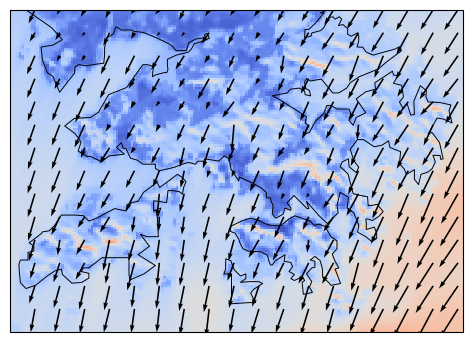

[48h] Saved 15 snapshot maps to: E:\CityU\Paper Code\06_AI_WRF_UCM\Figs\Fig5\publish


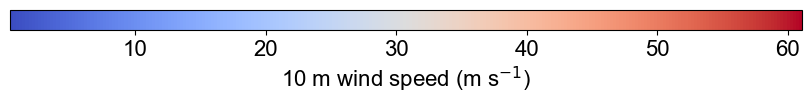

[48h] Saved standalone colorbar: E:\CityU\Paper Code\06_AI_WRF_UCM\Figs\Fig5\publish\colorbar_wind10_48h.tif


In [8]:
# ==============================
# 48h cases (append-only section)
# ==============================

uv10_d05_pangu_48h = xr.open_dataset('./data/uv10_d05_pangu_48h.nc')
uv10_d05_graphcast_48h = xr.open_dataset('./data/uv10_d05_graphcast_48h.nc')
uv10_d05_fengwu_48h = xr.open_dataset('./data/uv10_d05_fengwu_48h.nc')
uv10_d05_fuxi_48h = xr.open_dataset('./data/uv10_d05_fuxi_48h.nc')
uv10_d05_aurora_48h = xr.open_dataset('./data/uv10_d05_aurora_48h.nc')

MODEL_DATASETS_48H = {
    'pangu': uv10_d05_pangu_48h,
    'graphcast': uv10_d05_graphcast_48h,
    'fengwu': uv10_d05_fengwu_48h,
    'fuxi': uv10_d05_fuxi_48h,
    'aurora': uv10_d05_aurora_48h,
}

# Put 48h outputs next to the existing 24h ones, but with distinct names.
OUTPUT_DIR_48H = Path('./publish')
OUTPUT_DIR_48H.mkdir(parents=True, exist_ok=True)

# Sanity: 48h section expects helper functions from the 24h cell above.
required_helpers = ['_select_time', '_get_uv_latlon', '_plot_one_map', '_export_horizontal_colorbar', '_export_quiverkey', '_time_tag']
missing = [name for name in required_helpers if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing helper(s) from previous cell: " + ', '.join(missing) +
        "\nRun the 24h plotting cell above once to define shared helpers, then re-run this 48h cell."
    )

# --- 1) compute global vmin/vmax across the 15 snapshots (48h) ---
global_vmin_48h = np.inf
global_vmax_48h = -np.inf

for model_name, ds in MODEL_DATASETS_48H.items():
    for t in TIMES_TO_PLOT:
        ds_t = _select_time(ds, t)
        u10, v10, _, _ = _get_uv_latlon(ds_t)
        speed = np.hypot(u10.to_numpy(), v10.to_numpy())
        global_vmin_48h = min(global_vmin_48h, float(np.nanmin(speed)))
        global_vmax_48h = max(global_vmax_48h, float(np.nanmax(speed)))

norm_48h = mpl.colors.Normalize(vmin=global_vmin_48h, vmax=global_vmax_48h)
cmap_48h = mpl.colormaps[PLOT_CMAP]
print(f"[48h] Shared color range: vmin={global_vmin_48h:.3f}, vmax={global_vmax_48h:.3f} (m/s)")

# --- 2) plot and save 15 snapshot maps (48h) ---
preview_done_48h = False
for model_name, ds in MODEL_DATASETS_48H.items():
    for t in TIMES_TO_PLOT:
        ds_t = _select_time(ds, t)
        u10, v10, lat, lon = _get_uv_latlon(ds_t)
        speed = np.hypot(u10.to_numpy(), v10.to_numpy())

        fig = _plot_one_map(u10, v10, lat, lon, speed, norm=norm_48h, cmap=cmap_48h)

        out_path = OUTPUT_DIR_48H / f"wind10_{model_name}_{_time_tag(t)}_48h.tif"
        plt.savefig(out_path, dpi=DPI, bbox_inches='tight')

        if SHOW_PREVIEW and (not preview_done_48h) and (model_name == PREVIEW_MODEL) and (t == PREVIEW_TIME):
            plt.show()
            preview_done_48h = True

        plt.close(fig)

print(f"[48h] Saved 15 snapshot maps to: {OUTPUT_DIR_48H.resolve()}")

# --- 3) standalone shared colorbar (48h) ---
colorbar_path_48h = OUTPUT_DIR_48H / 'colorbar_wind10_48h.tif'
_export_horizontal_colorbar(norm=norm_48h, cmap=cmap_48h, out_path=colorbar_path_48h)
print(f"[48h] Saved standalone colorbar: {colorbar_path_48h.resolve()}")

# # --- 4) standalone arrow label (48h) ---
# quiverkey_path_48h = OUTPUT_DIR_48H / 'quiverkey_wind10_48h.tif'
# _export_quiverkey(out_path=quiverkey_path_48h)
# print(f"[48h] Saved standalone arrow label: {quiverkey_path_48h.resolve()}")

In [9]:
# ==============================
# VRMSE across all stations
# (24h vs 48h at three snapshots)
# ==============================

from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree


def _find_fig5_dirs() -> tuple[Path, Path]:
    """Return (data_dir, publish_dir) for Fig5.

    Robust to different CWDs (workspace root, Figs root, or Fig5).
    """
    cwd = Path.cwd().resolve()

    if (cwd / 'data' / 'mean_wspd_obs.csv').exists():
        fig5_dir = cwd
    elif (cwd / 'Fig5' / 'data' / 'mean_wspd_obs.csv').exists():
        fig5_dir = cwd / 'Fig5'
    else:
        parent_with_fig5 = None
        for p in [cwd, *cwd.parents]:
            if (p / 'Fig5' / 'data' / 'mean_wspd_obs.csv').exists():
                parent_with_fig5 = p
                break
        if parent_with_fig5 is None:
            raise FileNotFoundError(
                'Could not find Fig5/data/mean_wspd_obs.csv from current working directory. ',
                f'CWD={cwd}',
            )
        fig5_dir = parent_with_fig5 / 'Fig5'

    data_dir = fig5_dir / 'data'
    publish_dir = fig5_dir / 'publish'
    publish_dir.mkdir(parents=True, exist_ok=True)
    return data_dir, publish_dir


def _find_station_location_xlsx() -> Path:
    """Locate Fig4/data/weather_station_location.xlsx robustly."""
    cwd = Path.cwd().resolve()

    for candidate in [
        cwd / 'Fig4' / 'data' / 'weather_station_location.xlsx',
        cwd / 'Figs' / 'Fig4' / 'data' / 'weather_station_location.xlsx',
    ]:
        if candidate.exists():
            return candidate

    for p in [cwd, *cwd.parents]:
        candidate = p / 'Fig4' / 'data' / 'weather_station_location.xlsx'
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f'Could not locate Fig4/data/weather_station_location.xlsx from CWD={cwd}')


def _choose_station_sheet_and_columns(xlsx_path: Path, station_codes: list[str]) -> tuple[str, str, str, str]:
    """Heuristically pick (sheet, station_col, lat_col, lon_col).

    Works even if column headers are not English (e.g., 经度/纬度) by detecting
    lat/lon columns from plausible numeric ranges.
    """

    station_set = set([s.strip().lower() for s in station_codes])

    xl = pd.ExcelFile(xlsx_path)
    best_pick: tuple[int, int, str, str, str, str] | None = None
    # (valid_rows, station_matches, sheet, station_col, lat_col, lon_col)

    for sheet in xl.sheet_names:
        df = xl.parse(sheet_name=sheet)
        if df.empty:
            continue

        cols = list(df.columns)

        # 1) station column: maximize number of matches to station_set
        station_col = None
        station_matches = 0
        for c in cols:
            st = df[c].astype(str).str.strip().str.lower()
            m = int(st.isin(station_set).sum())
            if m > station_matches:
                station_matches = m
                station_col = c

        if station_col is None or station_matches == 0:
            continue

        st = df[station_col].astype(str).str.strip().str.lower()
        st_ok = st.isin(station_set)

        # 2) coordinate columns: detect by numeric ranges
        numeric = {}
        lat_scores: list[tuple[int, str]] = []
        lon_scores: list[tuple[int, str]] = []

        for c in cols:
            s = pd.to_numeric(df[c], errors='coerce')
            numeric[c] = s
            lat_cnt = int(s.between(20, 30).sum())
            lon_cnt = int(s.between(110, 120).sum())
            if lat_cnt > 0:
                lat_scores.append((lat_cnt, c))
            if lon_cnt > 0:
                lon_scores.append((lon_cnt, c))

        if not lat_scores or not lon_scores:
            continue

        lat_scores.sort(reverse=True)
        lon_scores.sort(reverse=True)

        top_lat = [c for _, c in lat_scores[:5]]
        top_lon = [c for _, c in lon_scores[:5]]

        for lat_col in top_lat:
            lat = numeric[lat_col]
            lat_ok = lat.between(20, 30)
            for lon_col in top_lon:
                if lon_col == lat_col:
                    continue
                lon = numeric[lon_col]
                lon_ok = lon.between(110, 120)

                valid_rows = int((st_ok & lat_ok & lon_ok).sum())
                if valid_rows < 5:
                    continue

                pick = (valid_rows, station_matches, sheet, station_col, lat_col, lon_col)
                if best_pick is None or pick[:2] > best_pick[:2]:
                    best_pick = pick

    if best_pick is None:
        raise ValueError('Could not auto-detect station/lat/lon columns in station location xlsx.')

    _, _, sheet, station_col, lat_col, lon_col = best_pick
    return sheet, station_col, lat_col, lon_col


def _winddir_to_uv(wspd: np.ndarray, wdir_deg_from: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Convert (speed, direction-from) to (u, v) in m/s.

    Convention: direction is FROM which the wind blows, in degrees clockwise from north.
    """
    theta = np.deg2rad(wdir_deg_from)
    u = -wspd * np.sin(theta)
    v = -wspd * np.cos(theta)
    return u, v


def _model_time_to_obs_timestamp(time_str: str) -> str:
    # '2025-09-23_21:00:00' -> '20250923 2100'
    date_part, clock_part = time_str.split('_')
    ymd = date_part.replace('-', '')
    hhmm = clock_part.replace(':', '')[:4]
    return f'{ymd} {hhmm}'


def _station_obs_uv_at_times(times_model_fmt: list[str]) -> tuple[list[str], pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Return (times_obs, loc_df, obs_u, obs_v)."""
    data_dir, _ = _find_fig5_dirs()
    wspd_path = data_dir / 'mean_wspd_obs.csv'
    wdir_path = data_dir / 'mean_wdir_obs.csv'

    times_obs = [_model_time_to_obs_timestamp(t) for t in times_model_fmt]

    df_wspd = pd.read_csv(wspd_path, dtype={'timestamp_utc': str})
    df_wdir = pd.read_csv(wdir_path, dtype={'timestamp_utc': str})
    for df in (df_wspd, df_wdir):
        df['timestamp_utc'] = df['timestamp_utc'].astype(str).str.strip()

    want = set(times_obs)
    sub_wspd = df_wspd[df_wspd['timestamp_utc'].isin(want)].copy()
    sub_wdir = df_wdir[df_wdir['timestamp_utc'].isin(want)].copy()

    sub_wspd = sub_wspd.set_index('timestamp_utc').loc[times_obs]
    sub_wdir = sub_wdir.set_index('timestamp_utc').loc[times_obs]

    station_cols = [c for c in sub_wspd.columns if c in set(sub_wdir.columns)]
    if len(station_cols) == 0:
        raise ValueError('No common station columns between mean_wspd_obs and mean_wdir_obs')

    sub_wspd = sub_wspd[station_cols]
    sub_wdir = sub_wdir[station_cols]

    # station locations
    station_xlsx = _find_station_location_xlsx()
    sheet, station_col, lat_col, lon_col = _choose_station_sheet_and_columns(station_xlsx, station_cols)
    df_loc = pd.read_excel(station_xlsx, sheet_name=sheet)
    df_loc = df_loc.rename(columns={station_col: 'station', lat_col: 'lat', lon_col: 'lon'}).copy()
    df_loc['station'] = df_loc['station'].astype(str).str.strip().str.lower()

    station_cols_norm = [s.strip().lower() for s in station_cols]
    loc = df_loc[df_loc['station'].isin(set(station_cols_norm))].copy()
    loc['lat'] = pd.to_numeric(loc['lat'], errors='coerce')
    loc['lon'] = pd.to_numeric(loc['lon'], errors='coerce')
    loc = loc.dropna(subset=['lat', 'lon']).copy()

    loc = loc.set_index('station')
    keep_order = [s for s in station_cols_norm if s in loc.index]
    loc = loc.loc[keep_order].reset_index()

    # normalize obs station column names to lowercase for alignment with loc
    sub_wspd.columns = [c.strip().lower() for c in sub_wspd.columns]
    sub_wdir.columns = [c.strip().lower() for c in sub_wdir.columns]

    # compute obs u/v per time (DataFrame: time x station)
    obs_u = pd.DataFrame(index=times_obs, columns=loc['station'].tolist(), dtype=float)
    obs_v = pd.DataFrame(index=times_obs, columns=loc['station'].tolist(), dtype=float)

    for tt in times_obs:
        wspd = pd.to_numeric(sub_wspd.loc[tt].reindex(loc['station'].values), errors='coerce').to_numpy(dtype=float)
        wdir = pd.to_numeric(sub_wdir.loc[tt].reindex(loc['station'].values), errors='coerce').to_numpy(dtype=float)
        missing = (np.isclose(wspd, 0.0) & np.isclose(wdir, 0.0)) | np.isnan(wspd) | np.isnan(wdir)
        u, v = _winddir_to_uv(wspd, wdir)
        u = u.astype(float)
        v = v.astype(float)
        u[missing] = np.nan
        v[missing] = np.nan
        obs_u.loc[tt] = u
        obs_v.loc[tt] = v

    return times_obs, loc, obs_u, obs_v


def _grid_indexer_for_latlon(lat2d: np.ndarray, lon2d: np.ndarray, station_lats: np.ndarray, station_lons: np.ndarray):
    """Return (flat_idx, in_domain_mask) for each station using nearest-neighbor on lat/lon grid."""
    lat2d = np.asarray(lat2d)
    lon2d = np.asarray(lon2d)

    # domain mask (avoid snapping far-away out-of-domain stations)
    lat_min, lat_max = float(np.nanmin(lat2d)), float(np.nanmax(lat2d))
    lon_min, lon_max = float(np.nanmin(lon2d)), float(np.nanmax(lon2d))
    in_domain = (station_lats >= lat_min) & (station_lats <= lat_max) & (station_lons >= lon_min) & (station_lons <= lon_max)

    pts = np.column_stack([lon2d.ravel(), lat2d.ravel()])
    tree = cKDTree(pts)
    q = np.column_stack([station_lons, station_lats])
    _, flat_idx = tree.query(q, k=1)
    flat_idx = flat_idx.astype(int)
    return flat_idx, in_domain


def _vrmse(u_mod: np.ndarray, v_mod: np.ndarray, u_obs: np.ndarray, v_obs: np.ndarray) -> float:
    # sqrt(mean((du)^2 + (dv)^2)) across stations
    du = u_mod - u_obs
    dv = v_mod - v_obs
    return float(np.sqrt(np.nanmean(du * du + dv * dv)))


def _compute_vrmse_table(model_datasets: dict, times_model_fmt: list[str], loc: pd.DataFrame, obs_u: pd.DataFrame, obs_v: pd.DataFrame) -> pd.DataFrame:
    if '_select_time' not in globals() or '_get_uv_latlon' not in globals():
        raise RuntimeError('Missing helper(s) _select_time/_get_uv_latlon. Run the 24h plotting cell once first.')

    times_obs = [_model_time_to_obs_timestamp(t) for t in times_model_fmt]
    station_lats = loc['lat'].to_numpy(dtype=float)
    station_lons = loc['lon'].to_numpy(dtype=float)

    out = pd.DataFrame(index=times_model_fmt, columns=list(model_datasets.keys()), dtype=float)

    # Build a grid indexer per model (in case grids differ)
    index_cache: dict[str, tuple[np.ndarray, np.ndarray]] = {}

    for model_name, ds in model_datasets.items():
        # Use first requested time to build the grid indexer
        ds0 = _select_time(ds, times_model_fmt[0])
        _, _, lat0, lon0 = _get_uv_latlon(ds0)
        flat_idx, in_domain = _grid_indexer_for_latlon(lat0.to_numpy(), lon0.to_numpy(), station_lats, station_lons)
        index_cache[model_name] = (flat_idx, in_domain)

        for t_model, t_obs in zip(times_model_fmt, times_obs):
            ds_t = _select_time(ds, t_model)
            u10, v10, lat, lon = _get_uv_latlon(ds_t)

            # If grid changes with time (unlikely), rebuild
            if (lat.shape != lat0.shape) or (lon.shape != lon0.shape):
                flat_idx, in_domain = _grid_indexer_for_latlon(lat.to_numpy(), lon.to_numpy(), station_lats, station_lons)
                index_cache[model_name] = (flat_idx, in_domain)

            flat_idx, in_domain = index_cache[model_name]
            u_flat = u10.to_numpy().ravel()[flat_idx]
            v_flat = v10.to_numpy().ravel()[flat_idx]

            u_obs = obs_u.loc[t_obs].to_numpy(dtype=float)
            v_obs = obs_v.loc[t_obs].to_numpy(dtype=float)

            # mask: obs missing or outside domain
            ok = in_domain & np.isfinite(u_obs) & np.isfinite(v_obs) & np.isfinite(u_flat) & np.isfinite(v_flat)
            if int(ok.sum()) == 0:
                out.loc[t_model, model_name] = np.nan
                continue

            out.loc[t_model, model_name] = _vrmse(u_flat[ok], v_flat[ok], u_obs[ok], v_obs[ok])

    return out


# --- compute VRMSE tables ---
if 'TIMES_TO_PLOT' not in globals():
    raise RuntimeError('TIMES_TO_PLOT not found. Run the configuration/plotting cells above first.')

times_obs, loc, obs_u, obs_v = _station_obs_uv_at_times(TIMES_TO_PLOT)
print(f'Stations with coordinates used for VRMSE: {len(loc)}')

vrmse_24h = _compute_vrmse_table(MODEL_DATASETS, TIMES_TO_PLOT, loc, obs_u, obs_v)
vrmse_48h = _compute_vrmse_table(MODEL_DATASETS_48H, TIMES_TO_PLOT, loc, obs_u, obs_v)

print('VRMSE (m/s) across all stations at 3 snapshots — 24h:')
display(vrmse_24h)
print('VRMSE (m/s) across all stations at 3 snapshots — 48h:')
display(vrmse_48h)

# Optional: export CSVs (disabled by default)
EXPORT_CSV = False
if EXPORT_CSV:
    _, publish_dir = _find_fig5_dirs()
    out24 = publish_dir / 'vrmse_station_vector_24h.csv'
    out48 = publish_dir / 'vrmse_station_vector_48h.csv'
    vrmse_24h.to_csv(out24, float_format='%.6f')
    vrmse_48h.to_csv(out48, float_format='%.6f')
    print(f'Wrote: {out24}')
    print(f'Wrote: {out48}')

Stations with coordinates used for VRMSE: 30
VRMSE (m/s) across all stations at 3 snapshots — 24h:


,pangu,graphcast,fengwu,fuxi,aurora
2025-09-23_21:00:00,13.605133,13.366190,18.464003,10.035279,18.698678
2025-09-23_22:00:00,15.610420,15.347495,20.267017,15.501574,20.740045
2025-09-23_23:00:00,13.577676,13.107167,21.530793,12.303112,20.866675


VRMSE (m/s) across all stations at 3 snapshots — 48h:


,pangu,graphcast,fengwu,fuxi,aurora
2025-09-23_21:00:00,12.317604,10.133486,16.000960,8.763374,15.471791
2025-09-23_22:00:00,14.509112,10.548925,16.905500,11.249685,19.879366
2025-09-23_23:00:00,14.208781,11.994875,18.676886,8.887356,23.373201
